## Comparison FLR - SIM

In [1]:
source_index = 6

#### Imports
Load the necessary modules

In [2]:
# imports
import os
os.environ["GPUBACKENDTOOLS_FORCE_BACKEND"] = "cuda12x"

from fastlisaresponse import ResponseWrapper, pyResponseTDI

from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral

from lisatools.detector import Orbits
from lisaconstants import ASTRONOMICAL_YEAR

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd
import os
import h5py
from scipy.signal.windows import tukey
from scipy.interpolate import CubicSpline
from h5py import File
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits

from scipy.interpolate import CubicSpline

from lisatools.detector import EqualArmlengthOrbits, Orbits
from lisatools.utils.utility import AET

from fastlisaresponse.utils.parallelbase import FastLISAResponseParallelModule
YRSID_SI = ASTRONOMICAL_YEAR
from fastlisaresponse import pyResponseTDI

from multiprocessing.sharedctypes import Value
import numpy as np
from typing import Optional, List
import warnings
from typing import Tuple
from copy import deepcopy

import time
import h5py

/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import few
import lisatools
import fastlisaresponse
import gpubackendtools
print(f'''
few:              {few.__version__}
lisatools:        {lisatools.__version__}
fastlisaresponse: {fastlisaresponse.__version__}
gpubackendtools:  {gpubackendtools.__version__}
''')


few:              2.0.0
lisatools:        1.2.8
fastlisaresponse: 1.2.1a0.post1.dev48+g66fa859db.d20260309
gpubackendtools:  0.1.1



#### Load correct dataset
We load the correct downsampled dataset containing 0.4Hz data. 

In [4]:
import glob
import os

scratch = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1'

# Use * as a wildcard for the parts that change
pattern = os.path.join(scratch, f'EMRI_731d_2.5s_L1_source{source_index}_*.h5')
files = glob.glob(pattern)
output = f'{os.getcwd()}/output'
if files:
    # If multiple versions, sort on stimestamps
    L1_file_path = sorted(files)[-1] 
    print(f"Selected: {L1_file_path}")
else:
    print("No file found for that source index.")

Selected: /scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1/EMRI_731d_2.5s_L1_source6_0_20251203T231104263787Z.h5


In [5]:
from mojito import MojitoL1File    
with MojitoL1File(L1_file_path) as f:

    # Timing parameters
    # l01_t0 = f['tdis/sampling'].attrs['t0']
    # l01_dt = f['tdis/sampling'].attrs['dt']
    # l01_size = f['tdis/sampling'].attrs['size']
    
    tdi_time_sampling = f.tdis.time_sampling
    tdi_dt = tdi_time_sampling.dt
    
    # TDI observables
    CENTRAL_FREQ = f.laser_frequency
    print(CENTRAL_FREQ)
    
    x2 = f.tdis.x2[:] / CENTRAL_FREQ  # TDI X2 observable in Hz
    y2 = f.tdis.y2[:] / CENTRAL_FREQ # TDI Y2 observable in Hz
    z2 = f.tdis.z2[:] / CENTRAL_FREQ # TDI Z2 observable in Hz
    

281600000000000.0


In [6]:
dt = delta_t = tdi_dt

In [7]:
x2.shape

(25246480,)

In [8]:
len_waveform = int(x2.shape[0] + 2* (550/dt + 1000))
# del x2, y2, z2
len_waveform

25248920

The difference in the length of the simulation and the length of the generated waveform: 

This is the extra part of the waveform that we need to generate: given as a number of samples

In [9]:
Time = len_waveform / ASTRONOMICAL_YEAR *dt

In [10]:
tdi_time_sampling.t0

97729939.827664

### Inspect Mojito timing
These functions come from the timing module in the simulation pipeline. 


In [11]:
def get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse,
    ) -> dict:
        """This function derives all timings relevant for Mojito, and generates the
        orbits file and groundtracking file.
        """
        # round up to integer multiple of `dt`
        duration_mojito_light = np.ceil(2.0 * ASTRONOMICAL_YEAR / dt) * dt

        # time reference from orbits file
        orbits = OEMOrbits.from_included(oemorbits)
        t0_orbits = float(orbits.t_start) + t_dltt_orbits

        # sizes: L1 has "+1" to cover full 2-year extent
        size_l1 = int(np.round(duration_mojito_light / dt)) + 1
        size_l0 = size_l1 + 2 * n_trim_lolipops
        size_strain = size_l0 + int(2 * np.ceil(t_strain_offset / dt))
        size_orbits = (
            int(
                np.ceil(((1 + 2 * window_jaxgbresponse) * size_l0 - 1) * dt / dt_orbits)
            )
            + 1
            + 2 * n_orbit_buffer
        )

        # time definitions
        t0_l0 = (
            t0_orbits + n_orbit_buffer * dt_orbits + window_jaxgbresponse * size_l0 * dt
        )
        t_init = t0_l0 - t_strain_offset
        timing_dict = {
            "dt": dt,
            "t_dltt_orbits": t_dltt_orbits,
            "dt_orbits": dt_orbits,
            "t_strain_offset": t_strain_offset,
            "n_trim_lolipops": n_trim_lolipops,
            "n_orbit_buffer": n_orbit_buffer,
            "window_jaxgbresponse": window_jaxgbresponse,
            "t0_orbits": t0_orbits,
            "size_l1": size_l1,
            "size_l0": size_l0,
            "size_strain": size_strain,
            "size_orbits": size_orbits,
            "t0_l0": t0_l0,
            "t_init": t_init,
        }
        return timing_dict

def create_orbits(oemorbits, timing, dense_orbits_path) -> None:
        """Create orbits file"""
        orbits = OEMOrbits.from_included(oemorbits)
        orbits.write(
            dense_orbits_path,    
            dt=timing["dt_orbits"],   
            size=timing["size_orbits"],
            t0=timing["t0_orbits"],
            mode="w",
        )


In [12]:
# create timing dictionary

t_dltt_orbits = 10.
dt_orbits = 5e5
t_strain_offset = 550
n_trim_lolipops = 1000
n_orbit_buffer = 10
window_jaxgbresponse = 0.5 

oemorbits =  "esa-trailing"

In [13]:
dt_orbits

500000.0

In [14]:
timing = get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [15]:
timing

{'dt': 2.5,
 't_dltt_orbits': 10.0,
 'dt_orbits': 500000.0,
 't_strain_offset': 550,
 'n_trim_lolipops': 1000,
 'n_orbit_buffer': 10,
 'window_jaxgbresponse': 0.5,
 't0_orbits': 61171239.327664,
 'size_l1': 25246521,
 'size_l0': 25248521,
 'size_strain': 25248961,
 'size_orbits': 274,
 't0_l0': 97731890.577664,
 't_init': 97731340.577664}

In [16]:
# timing
t0_l1 = tdi_time_sampling.t0
t0_l0 = t0_l1 - 1000*dt
t_init = t0_l0 - 550 

In [17]:
print(f'''
t0_l1 = {t0_l1}
t0_l0 = {t0_l0}
t_init = {t_init}
''')


t0_l1 = 97729939.827664
t0_l0 = 97727439.827664
t_init = 97726889.827664



## Build waveform object
Set up the waveform object with right keywords

In [18]:
from fastlisaresponse.utils.parallelbase import ParallelModuleBase
# Set up correct arguments
sum_kwargs = {
    "pad_output": True,
}

inspiral_kwargs = {
    "DENSE_STEPPING": 0,  # sparsely sampled trajectory
    "max_init_len": int(1e8),  
}

amplitude_kwargs = {
    # "max_init_len": int(1e8),  # all of the trajectories will be well under len = 1000
    # "use_gpu": True,
    # "file_dir":"/data/leuven/367/vsc36785/LISA/FastEMRIWaveforms/data"
}

waveform_kwargs = {
    'mode_selection_threshold': 0.0
}

In [19]:
class EMRIWave_base(ParallelModuleBase):
    def __init__(self, force_backend=None, 
                use_gpu=True, 
                 inspiral_kwargs=inspiral_kwargs,
                 sum_kwargs=sum_kwargs,
                 amplitude_kwargs=amplitude_kwargs,
                 mode_selection_threshold=1e-5,
                 t_init=33568152.5,
                 t0_orbits=33568152.5,
                 dt=5, 
                 n_samples=1000,
                 offset=550, # seconds
                 time=2.0
                ):
                 
        super().__init__(force_backend=force_backend)
        
        self.use_gpu = use_gpu
        self.mode_threshold = mode_selection_threshold
        
        # Initialize waveform generator

        self.waveform_gen = GenerateEMRIWaveform(
                "FastKerrEccentricEquatorialFlux",
                return_list=False,    # returns hp - i*hx as a complex cupy array
                inspiral_kwargs=inspiral_kwargs,
                sum_kwargs=sum_kwargs,
                amplitude_kwargs=amplitude_kwargs,
                frame="detector"
            )
        self.t_init = t_init
        self.t0_orbits = t0_orbits
    
    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]

    def __call__(self, *params, T=2, dt=5):
        '''
        Call FEW waveform model and return the strain as h_+ - ih_x
        '''
        # define correct time grid for waveform generation.
        waveform_kwargs['T'] = T
        waveform_kwargs['dt'] = dt
        waveform_kwargs['mode_selection_threshold'] = self.mode_threshold
        strain = self.waveform_gen(*params, **waveform_kwargs)

        return strain

In [20]:
# get t0_orbits as done in Mojito simulation
orbits = OEMOrbits.from_included(oemorbits)
t0_orbits = float(orbits.t_start) + t_dltt_orbits

n_samples = 1000 # necessary to do the TDI delays
Tobs = 2 # years
offset = 550  # seconds

T = Tobs + (2* offset + 2*n_samples*dt)/ASTRONOMICAL_YEAR

use_gpu=True
t_smooth=0
waveform_model='Kerr'
mode_selection_threshold = 0.0

f_s = 1/dt   
home_folder = os.getcwd()

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [ ]:
emri_waveform = EMRIWave_base(use_gpu=use_gpu, 
                         mode_selection_threshold=mode_selection_threshold,
                         t0_orbits=t0_orbits,
                         t_init=t_init,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=offset, # seconds
                        )

#### Get noise data

In [ ]:
# load noise estimates
CENTRAL_FREQ = 281600000000000.0
noise_file = f"{scratch}/../../NOISE/L1/NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5"

with h5py.File(noise_file, "r") as f:
    xyz_noise_estimate = np.mean(f['noise_estimates/XYZ'][:], axis=0) / CENTRAL_FREQ**2
    fmin_noise_psd = f['noise_estimates/log_frequency_sampling'].attrs['fmin']
    fmax_noise_psd = f['noise_estimates/log_frequency_sampling'].attrs['fmax']
    size_noise_psd = f['noise_estimates/log_frequency_sampling'].attrs['size']

    noise_freqs = np.logspace(np.log10(fmin_noise_psd), np.log10(fmax_noise_psd), size_noise_psd)

In [ ]:
# define noise psd interpolant

freqs_inband_np = np.asarray(freqs_inband.get())

splined_noise_psd = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, i])(freqs_inband_np) for i in range(3)
])

splined_noise_csd_real = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, j].real)(freqs_inband_np) for i in range(3) for j in range(i, 3)
])

splined_noise_psd_imag = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, j].imag)(freqs_inband_np) for i in range(3) for j in range(i, 3)   
])


In [ ]:
# now re-assemble the covariance matrix
covariance_matrices = np.zeros((3, 3, len(freqs_inband)), dtype=complex)
for i in range(3):
    covariance_matrices[i, i, :] = splined_noise_psd[i]
    for j in range(i+1, 3):
        covariance_matrices[i, j, :] = splined_noise_csd_real[i*3 + j - (i+1)*i//2] + 1j * splined_noise_psd_imag[i*3 + j - (i+1)*i//2]
        covariance_matrices[j, i, :] = np.conj(covariance_matrices[i, j, :])

In [ ]:
# function to stabilize the inversion of the covariance matrix
def stabilize_covariance_for_inversion(
    cov,
    psd_floor=1e-45,
    smooth_window_logfreq=15,
    return_inverse=True,
):
    """
    Stabilize covariance by smoothing magnitude in log-frequency space.

    Fast and robust: smooths away dips/spikes without costly eigendecomposition.

    Parameters
    ----------
    cov : np.ndarray, shape (n_ch, n_ch, n_freq)
        Complex covariance matrices.
    psd_floor : float
        Floor for smoothed magnitudes.
    smooth_window_logfreq : int
        Size of smoothing window in log-frequency (samples). Use ~10-20.
    return_inverse : bool
        If True, also return stable inverse.

    Returns
    -------
    cov_stable : np.ndarray, shape (n_ch, n_ch, n_freq)
        Stabilized Hermitian positive-definite covariance.
    inv_cov_stable : np.ndarray, optional
        Stable matrix inverse (via np.linalg.inv per frequency).
    """
    from scipy.ndimage import uniform_filter1d
    
    cov = np.asarray(cov, dtype=np.complex128)
    n_ch, _, n_f = cov.shape

    # 1) Extract magnitude and phase per matrix element
    mag = np.abs(cov)  # Shape: (n_ch, n_ch, n_freq)
    phase = np.angle(cov)  # Shape: (n_ch, n_ch, n_freq)

    # 2) Smooth magnitude in log-frequency space for each element
    mag_smooth = np.zeros_like(mag)
    for i in range(n_ch):
        for j in range(n_ch):
            # Log-smooth: apply uniform filter on log of magnitude
            log_mag = np.log(np.maximum(mag[i, j, :], psd_floor))
            log_mag_smooth = uniform_filter1d(log_mag, size=smooth_window_logfreq, mode='nearest')
            mag_smooth[i, j, :] = np.exp(log_mag_smooth)

    # 3) Reconstruct complex values with original phase
    cov_smooth = mag_smooth * np.exp(1j * phase)

    # 4) Enforce Hermitian structure
    cov_stable = 0.5 * (cov_smooth + cov_smooth.conj().transpose(1, 0, 2))

    # 5) Ensure diagonal is real and positive
    for k in range(n_f):
        d = np.real(np.diag(cov_stable[:, :, k]))
        d = np.maximum(d, psd_floor)
        np.fill_diagonal(cov_stable[:, :, k], d)

    if return_inverse:
        inv_cov_stable = np.empty_like(cov_stable)
        for k in range(n_f):
            inv_cov_stable[:, :, k] = np.linalg.inv(cov_stable[:, :, k])
        return cov_stable, inv_cov_stable

    return cov_stable

In [ ]:
# Apply stabilization

covariance_matrices_stable, invC_stable = stabilize_covariance_for_inversion(
    covariance_matrices,
    psd_floor=1e-45,
    smooth_window_logfreq=15,  # Tune this: larger = smoother
)

# Apply prefactor
pre_fact = 2 * dt / N_t
invC_for_ip = pre_fact * invC_stable

### test waveform module

In [27]:
emri_test = emri_waveform(*params_mojito, T=Tobs, dt=dt)

(36900450.53134839, 36902664.66908716)

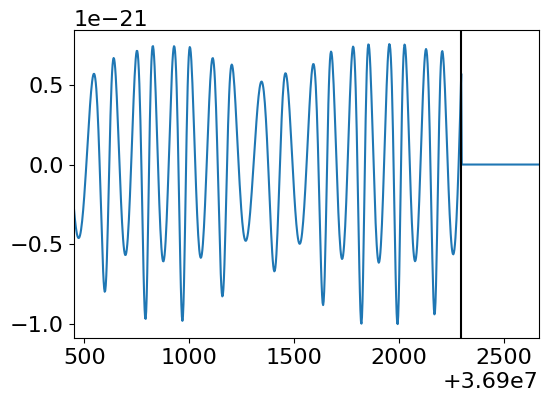

In [28]:
time = np.arange(len(emri_test)) * dt

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(time, emri_test.real.get())
ax.axvline(params['TimeCoalescenceSSBFrame'], color='black')

ax.set_xlim([0.99995* params['TimeCoalescenceSSBFrame'], 1.00001*params['TimeCoalescenceSSBFrame']])

### Get source parameters
get the source parameters from the catalog

In [ ]:
source_index = 0

In [ ]:
from mojito.download import get_source_params

# Get source parameters for mbhb brick, source ID 12
params = get_source_params("emri", source_id=source_index, username='bert-depoorter', token='2c7#QBB9DTh8QgJPpw')

In [ ]:
params

In [ ]:
def icrs_to_ecliptic(ra, dec):
    """Convert ICRS coordinates (ra, dec) to ecliptic coordinates (lambda, beta)."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    icrs_coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad, frame='icrs')
    ecliptic_coord = icrs_coord.barycentrictrueecliptic

    lambda_ecl = ecliptic_coord.lon.rad
    beta_ecl = ecliptic_coord.lat.rad

    return lambda_ecl, beta_ecl

In [ ]:
ra = params['RightAscension']
dec = params['Declination']

lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)
qS_ecl = np.pi / 2 - beta_ecl
phiS_ecl = lam_ecl


In [ ]:
# extract source parameters
params_mojito = [
    params['PrimaryMassSSBFrame'],
    params['SecondaryMassSSBFrame'],
    params['PrimarySpinParameter'], #* np.sign(np.cos(params['InclinationAngle'])),
    params['SemiLatusRectum'],
    params['Eccentricity'],
    np.cos(params['InclinationAngle']),
    params['LuminosityDistance']*1e-3,
    qS_ecl,  # np.pi/2 - beta
    phiS_ecl,  # lambda
    params['PolarAnglePrimarySpin'],
    params['AzimuthalAnglePrimarySpin'],
    params['AzimuthalPhase'],
    params['PolarPhase'],
    params['RadialPhase'],
]

In [2]:
# get source data
# Use * as a wildcard for the parts that change
pattern = os.path.join(scratch, f'EMRI_731d_2.5s_L1_source{source_index}_*.h5')
files = glob.glob(pattern)
output = f'{os.getcwd()}/output'
if files:
    # If multiple versions, sort on stimestamps
    L1_file_path = sorted(files)[-1] 
    print(f"Selected: {L1_file_path}")
else:
    print("No file found for that source index.")


NameError: name 'os' is not defined

In [ ]:
from mojito import MojitoL1File    
with MojitoL1File(L1_file_path) as f:

    # Timing parameters
    # l01_t0 = f['tdis/sampling'].attrs['t0']
    # l01_dt = f['tdis/sampling'].attrs['dt']
    # l01_size = f['tdis/sampling'].attrs['size']
    
    tdi_time_sampling = f.tdis.time_sampling
    tdi_dt = tdi_time_sampling.dt
    
    # TDI observables
    CENTRAL_FREQ = f.laser_frequency
    print(CENTRAL_FREQ)
    
    x2 = f.tdis.x2[:] / CENTRAL_FREQ  # TDI X2 observable in Hz
    y2 = f.tdis.y2[:] / CENTRAL_FREQ # TDI Y2 observable in Hz
    z2 = f.tdis.z2[:] / CENTRAL_FREQ # TDI Z2 observable in Hz
    

### Set up response

In [29]:
orbit_file= f'{home_folder}/esa-trailing-orbits-mojito_validation_test_2.h5'
force_backend = 'cuda12x'
esa = Orbits(filename=orbit_file, 
            use_gpu=use_gpu, 
            force_backend=force_backend, 
            linear_interp_setup=False,
            t0=t0_orbits)

In [30]:
len(params_mojito)

14

In [31]:
force_backend = "cuda12x" if use_gpu else None

index_beta = 7
index_lambda = 8

tdi_kwargs = {
    'tdi': '2nd generation',
    'tdi_chan': 'XYZ',
    'order': 39,
}

In [32]:
from fastlisaresponse.tdiconfig import TDIConfig
tdi_kwargs_esa = dict(
            orbits=esa,
            order=40,
            tdi=TDIConfig('2nd generation'),
            tdi_chan="XYZ",
        )

In [33]:
emri_TDI_list = ResponseWrapper(
    emri_waveform,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t_init,
    t_buffer = 10000.0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    force_backend=force_backend,
    remove_sky_coords=False,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=False,  # False if using polar angle (theta)
    remove_garbage=False,  # removes the beginning of the signal that has bad information
    # orbits=esa,
    **tdi_kwargs_esa,
)

In [34]:
def emri_TDI(*params):
    return cp.asarray(emri_TDI_list(*params))

In [35]:
chans = emri_TDI(*params_mojito)

In [36]:
time = np.arange(len(chans[0])) * dt / YRSID_SI

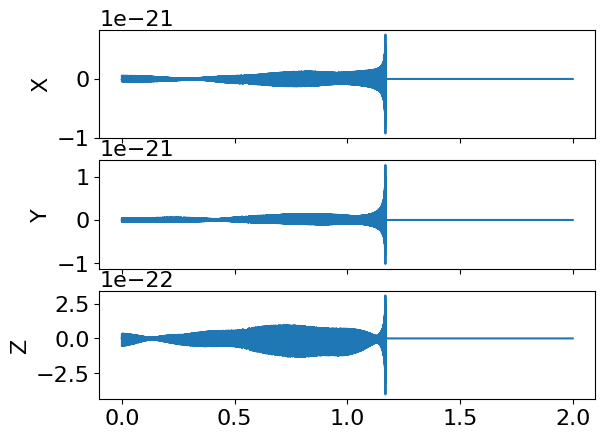

In [37]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[::10], chans[i].get()[::10])
    # ax[i].set_xlim([1.999, 2.001])
    ax[i].set_ylabel(lab)

In [38]:
chans.shape

(3, 25248959)

In [39]:
x2.shape

(25246480,)

In [40]:
25248959 - 25246480

2479

In [41]:
850.5 / dt

340.2

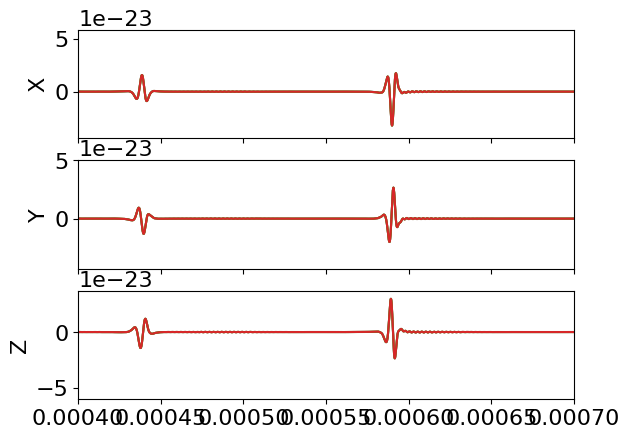

In [42]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[:10000], chans[i].get()[:10000])
    ax[0].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, x2[:10000])
    ax[1].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, y2[:10000])
    ax[2].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, z2[:10000])
    ax[i].set_xlim([0.0004, 0.0007])
    ax[i].set_ylabel(lab)

### Comparison plots

In [43]:
dt

2.5

In [44]:
time_sim_L1 = np.arange(t_init + 850.5, x2.shape[0]*delta_t + t_init + 850.5, dt)[:-1]  
time_flr_L1 = np.arange(t_init, chans.shape[1]*delta_t + t_init, dt)[:-1] 

In [45]:
len(chans[0])

25248959

In [46]:
time_flr_L1.shape

(25248959,)

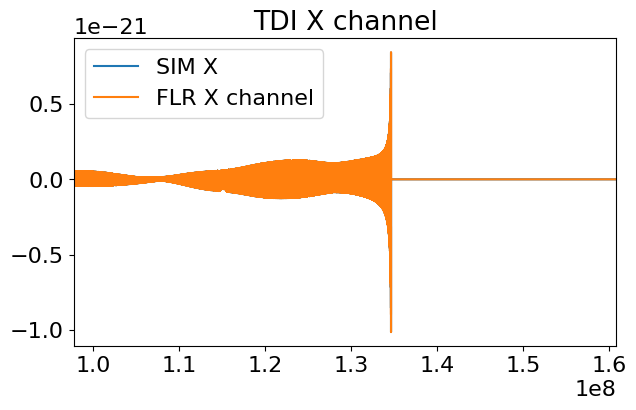

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, x2, label='SIM X')   
ax.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')
plt.show()
fig.clear()

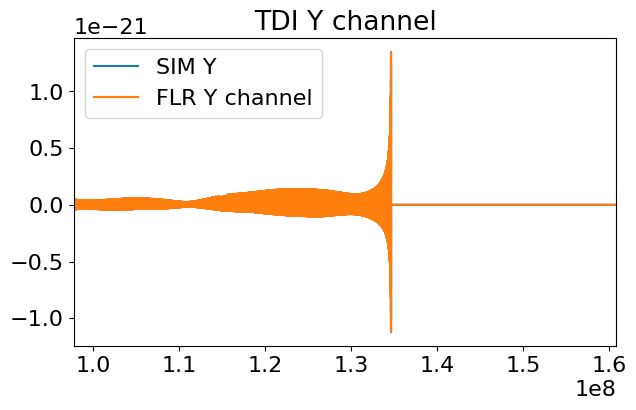

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, y2, label='SIM Y')   
ax.plot(time_flr_L1, chans[1].get(), label='FLR Y channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Y channel')
plt.show()
fig.clear()

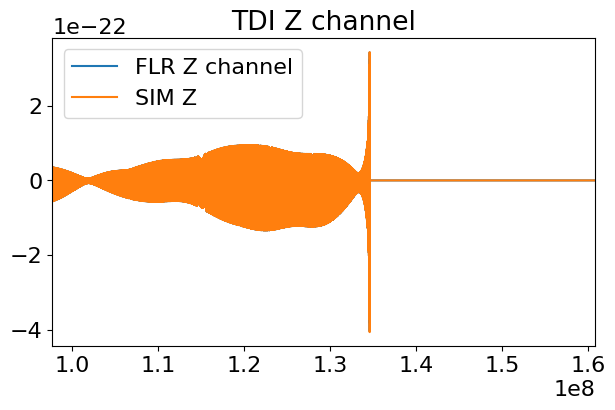

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.plot(time_sim_L1, z2, label='SIM Z')   
# ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Z channel')
plt.show()
fig.clear()

In [49]:
T_plunge = params['TimeCoalescenceSSBFrame'] + t_init - 50.5

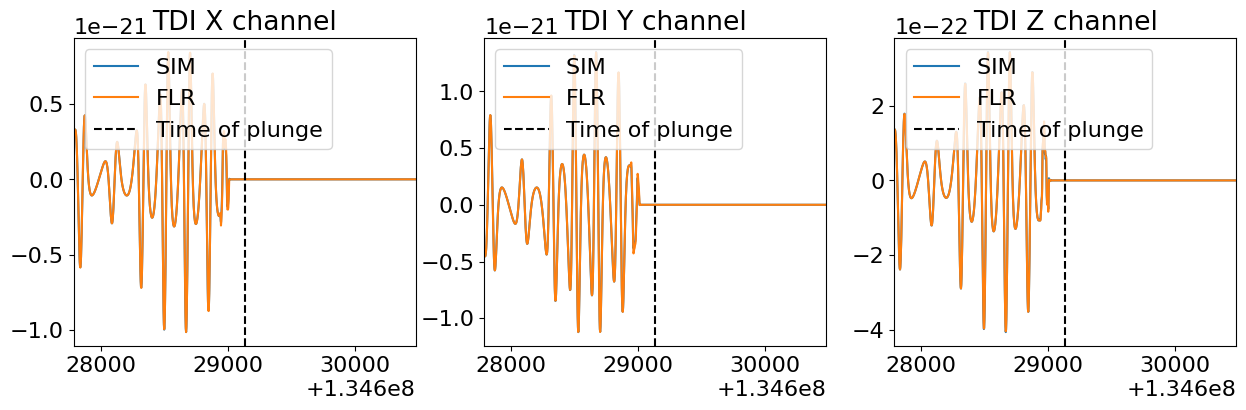

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1, sim_data[i], label=f'SIM ')   
    ax[i].plot(time_flr_L1, chans[i].get(), label=f'FLR')
    ax[i].set_xlim([0.99999 * T_plunge, 1.00001 * T_plunge])
    ax[i].axvline(T_plunge, linestyle='--', color='black', label='Time of plunge')
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

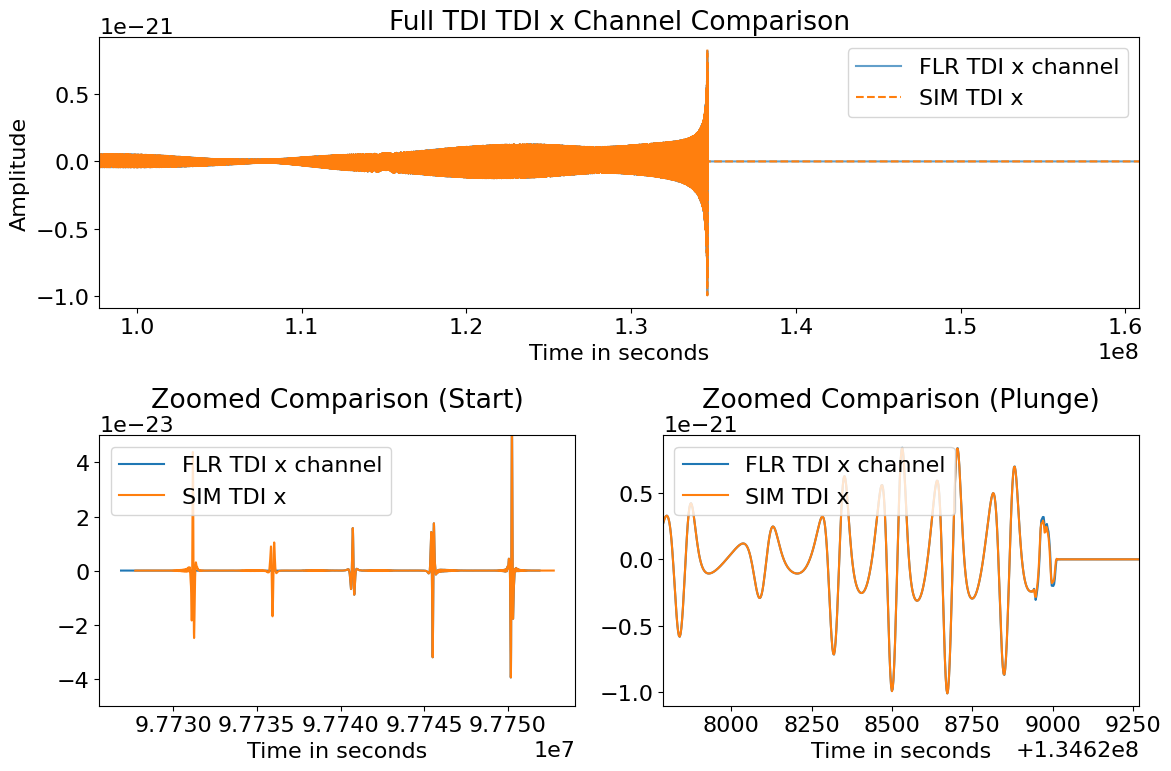

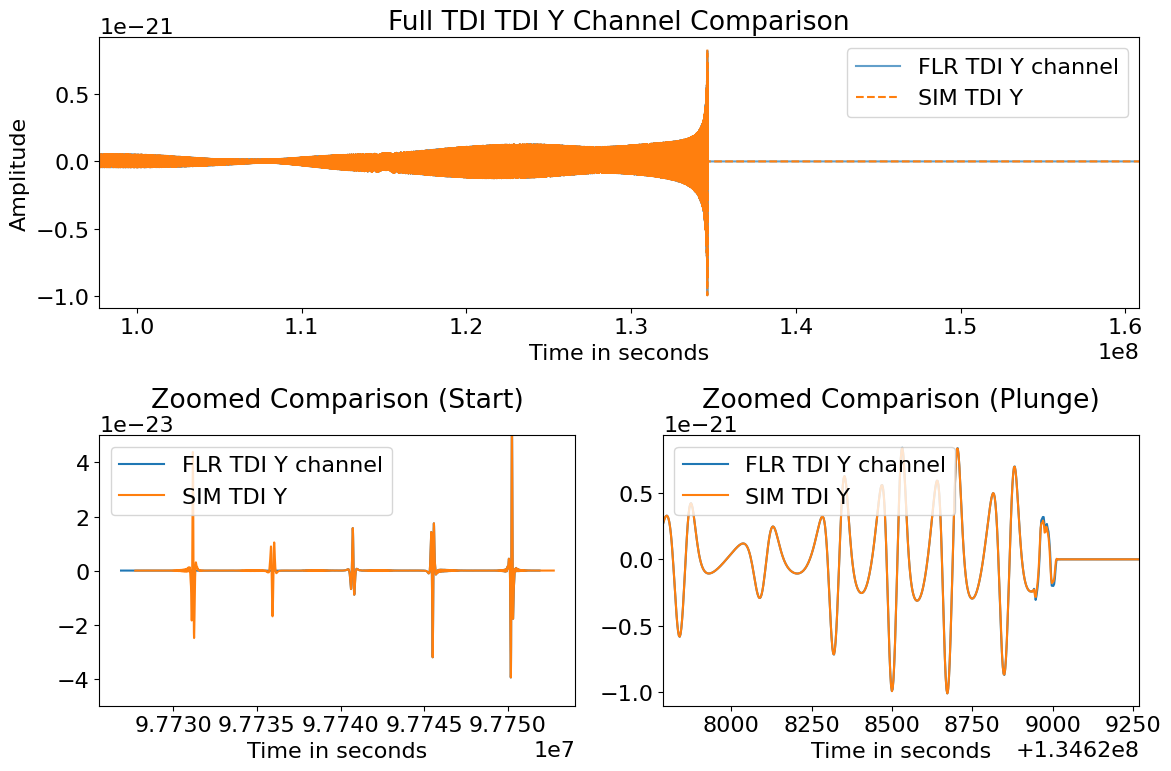

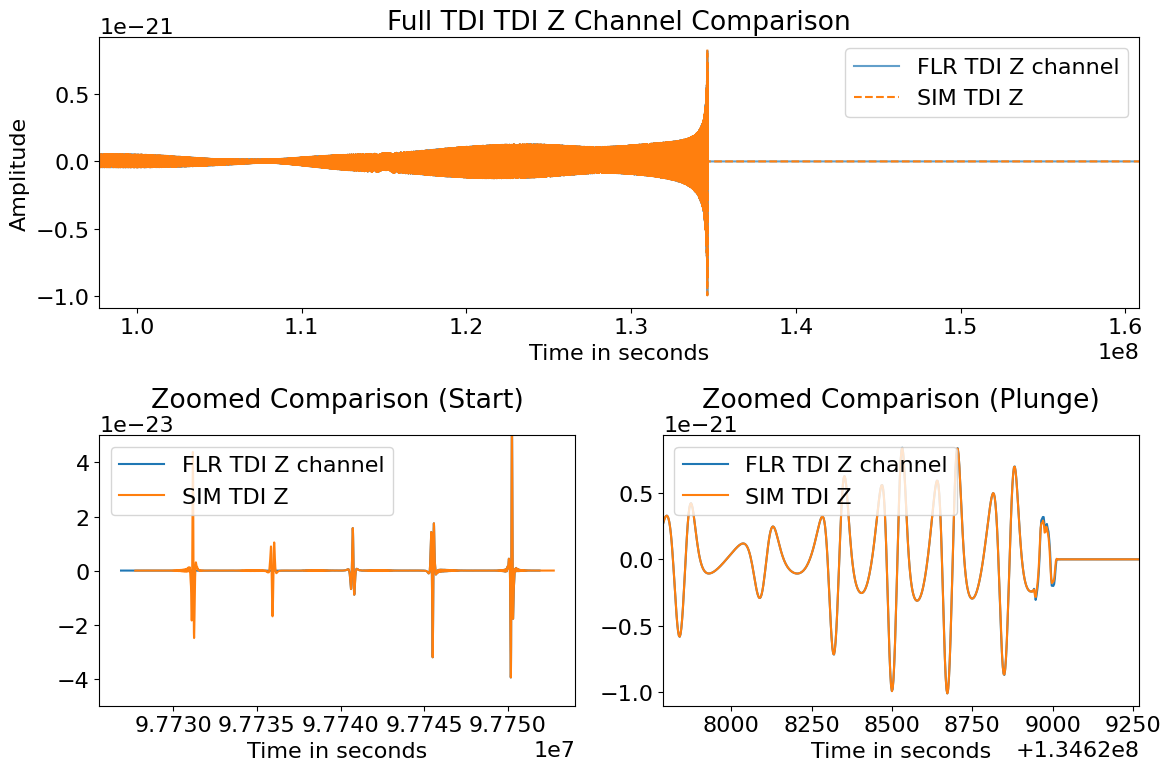

In [51]:
channels = ['TDI x', 'TDI Y', 'TDI Z']
for i, chan in enumerate(channels):
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 2)

    # panel with full thing
    ax_top = fig.add_subplot(gs[0, :]) # Spans row 0, all columns
    ax_top.plot(time_flr_L1[::4], chans[0][::4].get(), label=f'FLR {chan} channel', alpha=0.7)
    ax_top.plot(time_sim_L1[::4], x2[::4], label=f'SIM {chan}', linestyle='--')
    ax_top.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
    ax_top.set_title(f'Full TDI {chan} Channel Comparison')
    ax_top.legend(loc='upper right')
    ax_top.set_xlabel('Time in seconds')
    ax_top.set_ylabel('Amplitude')

    # bottom left
    ax_left = fig.add_subplot(gs[1, 0])
    ax_left.plot(time_flr_L1[:10000], chans[0][:10000].get(), label=f'FLR {chan} channel')
    ax_left.plot(time_sim_L1[:10000], x2[:10000], label=f'SIM {chan}')   
    # ax_left.set_xlim([(time_sim_L1[0])+1000*dt, (time_sim_L1[0]+ 0.00005)+8000*dt])
    ax_left.set_ylim([-5e-23, 5e-23])
    ax_left.legend(loc='upper left')
    ax_left.set_xlabel('Time in seconds')
    ax_left.set_title('Zoomed Comparison (Start)')

    # Bottom right
    ax_right = fig.add_subplot(gs[1, 1])
    ax_right.plot(time_flr_L1, chans[0].get(), label=f'FLR {chan} channel')
    ax_right.plot(time_sim_L1, x2, label=f'SIM {chan}')   
    ax_right.set_xlim([0.99999*T_plunge, 1.000001*T_plunge])
    # ax_right.set_xlim([(4.26612)*YRSID_SI/dt, (4.26615)*YRSID_SI/dt])
    ax_right.legend(loc='upper left')
    ax_right.set_xlabel('Time in seconds')
    ax_right.set_title('Zoomed Comparison (Plunge)')

    plt.tight_layout()
    plt.show()
    fig.savefig(f'{output}/source_{source_index}/{chan}_TD_comparison.png', dpi=300)

    fig.clear()

### Mismatch and SNR computations

In [52]:
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.sensitivity import SensitivityMatrix

from lisatools.domains import TDSettings, FDSettings, FDSignal, TDSignal

In [53]:
chans.shape

(3, 25248959)

In [54]:
tdi_channels_here = np.array([tdi_channel.get() for tdi_channel in chans])

In [55]:
# now spline interpolate the tdi channels to the same time array as the data
from scipy.interpolate import CubicSpline
window = tukey(len(time_sim_L1), alpha=0.01)

xyz_splined = np.array([
    CubicSpline(time_flr_L1, chan)(time_sim_L1) for chan in tdi_channels_here
])

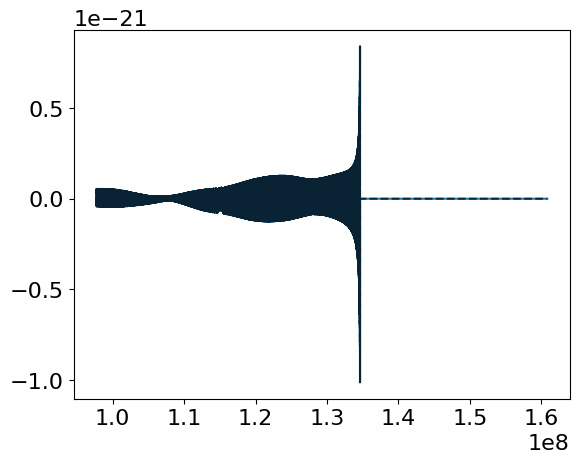

In [56]:
NPLOT = int(1e9)

plt.plot(time_sim_L1[:NPLOT], x2[:NPLOT], label='L1 X')
plt.plot(time_sim_L1[:NPLOT], xyz_splined[0][:NPLOT], alpha=0.7, label='EMRI waveform X', c='k', ls='--')


In [57]:
data = cp.asarray([x2, y2, z2])

In [58]:
xyz_residual = data - cp.asarray(xyz_splined)

In [59]:
xyz_residual_windowed = xyz_residual * cp.asarray(window)


In [60]:
# window signal
xyz_residual_windowed = xyz_residual * cp.asarray(window)
xyz_data_windowed = data * cp.asarray(window)
xyz_splined_windowed = cp.asarray(xyz_splined) * cp.asarray(window)

# apply fft
xyz_residual_fft = cp.fft.rfft(xyz_residual_windowed, axis=1)
xyz_data_fft = cp.fft.rfft(xyz_data_windowed, axis=1)
xyz_splined_fft = cp.fft.rfft(xyz_splined_windowed, axis=1)


N_t = len(data[0])
freqs = cp.fft.rfftfreq(N_t, d=dt)

f_max = 1/(2*dt) # Nyquist frequency
f_min = 1e-5 # minimum frequency to consider
mask = (freqs >= f_min) & (freqs <= f_max)
freqs_inband = freqs[mask]

# filter frequencies
xyz_data_fft_inband = xyz_data_fft[:, mask]
xyz_splined_fft_inband = xyz_splined_fft[:, mask]
xyz_residual_fft_inband = xyz_residual_fft[:, mask]


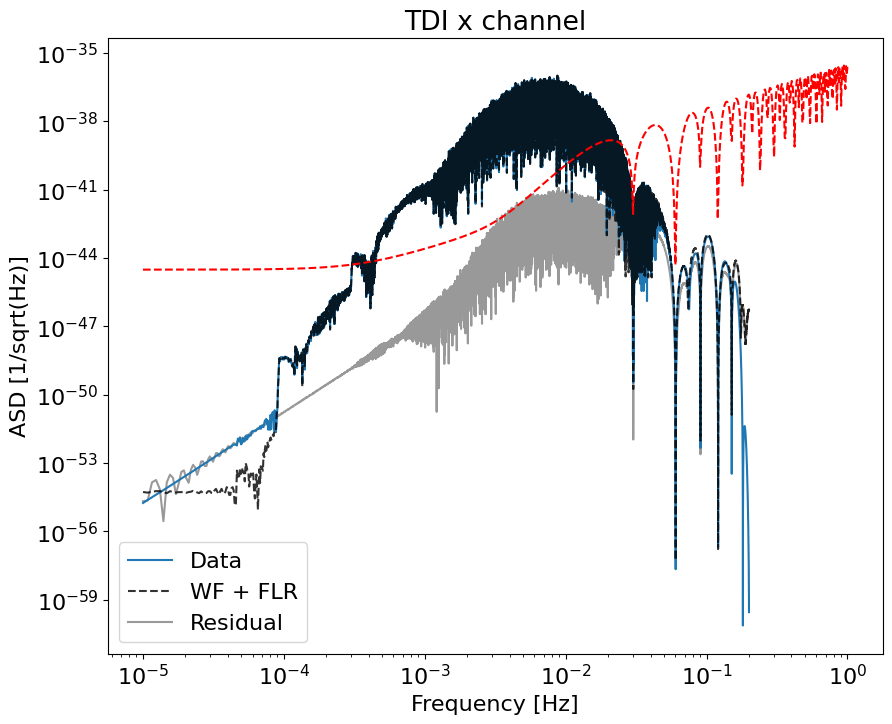

<Figure size 640x480 with 0 Axes>

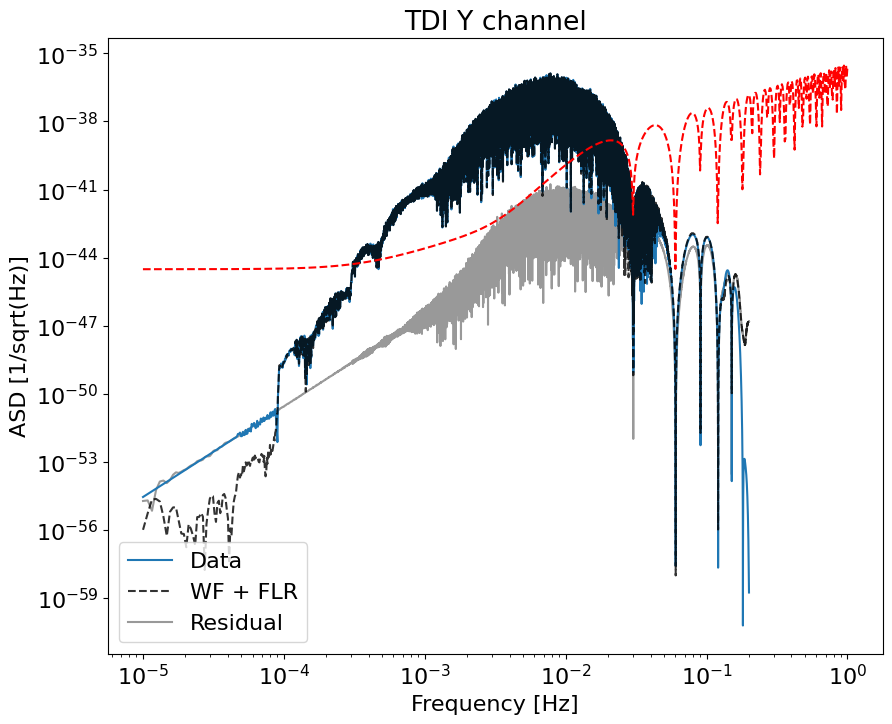

<Figure size 640x480 with 0 Axes>

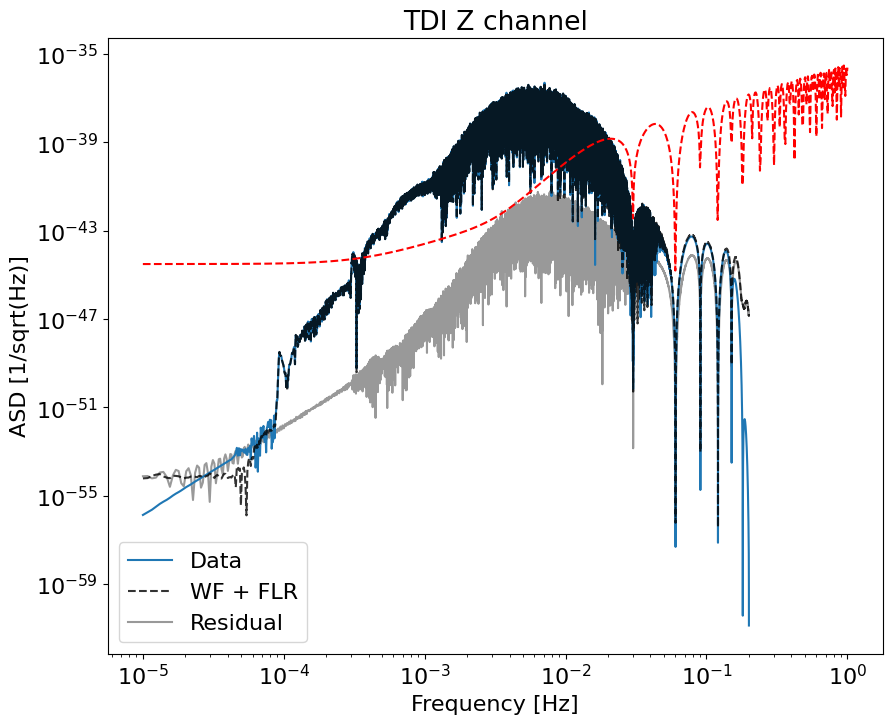

<Figure size 640x480 with 0 Axes>

In [65]:
# make plots

channels = ['TDI x', 'TDI Y', 'TDI Z']
for i, chan in enumerate(channels):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    DecimFactor = 50
    axs.loglog(freqs_inband[::DecimFactor].get(), np.abs(xyz_data_fft_inband[i, ::DecimFactor].get())**2, 
               label='Data')
    axs.loglog(freqs_inband[::DecimFactor].get(), np.abs(xyz_splined_fft_inband[i, ::DecimFactor].get())**2, 
               label='WF + FLR', c='k', ls='--', alpha=0.8)
    axs.loglog(freqs_inband[::DecimFactor].get(), np.abs(xyz_residual_fft_inband[i, ::DecimFactor].get())**2, 
               c='gray', alpha=0.8, zorder=0, label='Residual')
    
    axs.loglog(noise_freqs, np.abs(xyz_noise_estimate[:, i, i]), linestyle='dashed', color='red')

    axs.set_title(f"{chan} channel")
    axs.legend(loc='lower left')

    axs.set_xlabel("Frequency [Hz]")
    axs.set_ylabel("ASD [1/sqrt(Hz)]")


    # plt.ylim(1e-26, 1e-17)

    plt.show()
    plt.savefig(f'{output}/source_{source_index}/{chan}_FD_comparison.png')
    #plt.xlim(1e-5, 0.2)

    fig.clear()

We see some mismatch at the lower and upper frequency bounds. At the high frequencies this may be attributed to the downsampling applied on the full 4Hz simulated data. Need to check this by generating the data at 4Hz with FLR. Maybe too memory-intensive to perform well. 

#### Personal SNR function
This function works but suffers from numerical instability when inverting the covariance matrix, due to negative and complex values in the CSD arrays. This should be addressed more robustly.

In [69]:
freqs_inband_np.shape

(12622609,)

In [70]:
covariance_matrices.shape

(3, 3, 12622609)

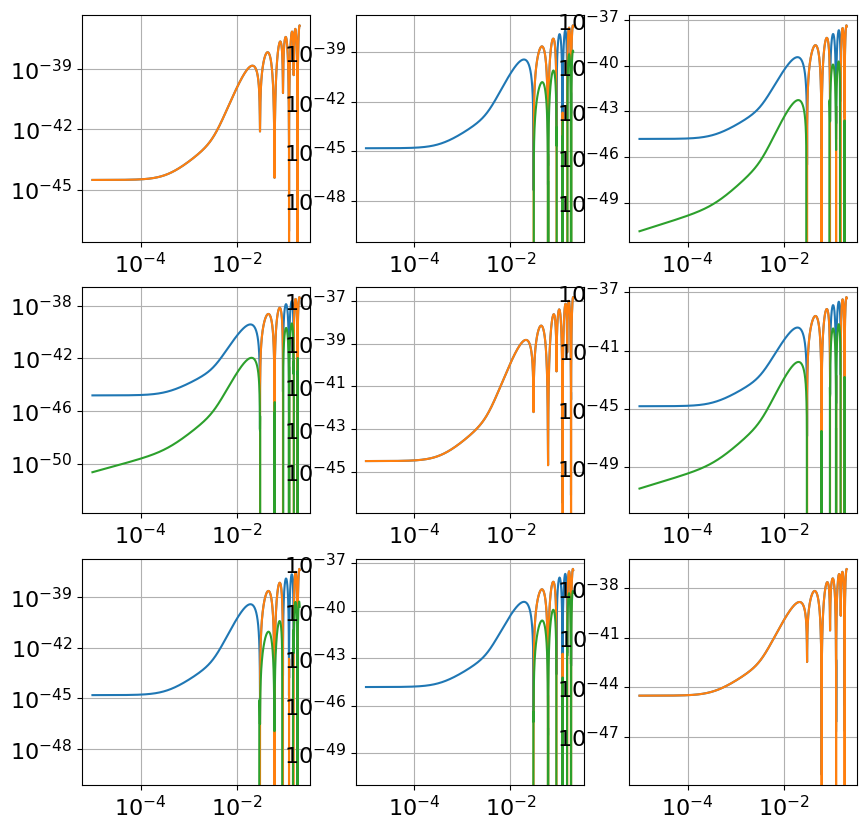

In [74]:
fig, axs = plt.subplots(3,3, figsize=(10, 10))

for i in range(3):
    for j in range(3):
        axs[i, j].loglog(freqs_inband_np[::5], np.abs(covariance_matrices[i, j, :][::5]), label='abs')
        axs[i, j].loglog(freqs_inband_np[::5], np.real(covariance_matrices[i, j, :][::5]), label='real')
        axs[i, j].loglog(freqs_inband_np[::5], np.imag(covariance_matrices[i, j, :][::5]), label='imag')
        axs[i, j].grid(True, which='both')


In [71]:
# function to stabilize the inversion of the covariance matrix
def stabilize_covariance_for_inversion(
    cov,
    psd_floor=1e-45,
    smooth_window_logfreq=15,
    return_inverse=True,
):
    """
    Stabilize covariance by smoothing magnitude in log-frequency space.

    Fast and robust: smooths away dips/spikes without costly eigendecomposition.

    Parameters
    ----------
    cov : np.ndarray, shape (n_ch, n_ch, n_freq)
        Complex covariance matrices.
    psd_floor : float
        Floor for smoothed magnitudes.
    smooth_window_logfreq : int
        Size of smoothing window in log-frequency (samples). Use ~10-20.
    return_inverse : bool
        If True, also return stable inverse.

    Returns
    -------
    cov_stable : np.ndarray, shape (n_ch, n_ch, n_freq)
        Stabilized Hermitian positive-definite covariance.
    inv_cov_stable : np.ndarray, optional
        Stable matrix inverse (via np.linalg.inv per frequency).
    """
    from scipy.ndimage import uniform_filter1d
    
    cov = np.asarray(cov, dtype=np.complex128)
    n_ch, _, n_f = cov.shape

    # 1) Extract magnitude and phase per matrix element
    mag = np.abs(cov)  # Shape: (n_ch, n_ch, n_freq)
    phase = np.angle(cov)  # Shape: (n_ch, n_ch, n_freq)

    # 2) Smooth magnitude in log-frequency space for each element
    mag_smooth = np.zeros_like(mag)
    for i in range(n_ch):
        for j in range(n_ch):
            # Log-smooth: apply uniform filter on log of magnitude
            log_mag = np.log(np.maximum(mag[i, j, :], psd_floor))
            log_mag_smooth = uniform_filter1d(log_mag, size=smooth_window_logfreq, mode='nearest')
            mag_smooth[i, j, :] = np.exp(log_mag_smooth)

    # 3) Reconstruct complex values with original phase
    cov_smooth = mag_smooth * np.exp(1j * phase)

    # 4) Enforce Hermitian structure
    cov_stable = 0.5 * (cov_smooth + cov_smooth.conj().transpose(1, 0, 2))

    # 5) Ensure diagonal is real and positive
    for k in range(n_f):
        d = np.real(np.diag(cov_stable[:, :, k]))
        d = np.maximum(d, psd_floor)
        np.fill_diagonal(cov_stable[:, :, k], d)

    if return_inverse:
        inv_cov_stable = np.empty_like(cov_stable)
        for k in range(n_f):
            inv_cov_stable[:, :, k] = np.linalg.inv(cov_stable[:, :, k])
        return cov_stable, inv_cov_stable

    return cov_stable

In [73]:
def inner_prod_tdi(a_fft, b_fft, cov_inv_matrices):
    """
    Compute noise-weighted inner product for TDI multi-channel data with correlated noise.
    Time-Delay Interferometry (TDI) produces three channels (X, Y, Z) with correlated
    noise. This function computes the proper inner product accounting for these
    correlations using the inverse covariance matrix.
    Mathematical form:
        ⟨a|b⟩ = 2 Re[Σₖ aₖ† Σₖ⁻¹ bₖ]
    where at each frequency bin k:
        - aₖ, bₖ are 3D complex vectors [X_k, Y_k, Z_k]
        - Σₖ⁻¹ is the 3×3 inverse covariance matrix
    Parameters
    ----------
    a_fft : array-like, complex, shape (3, n_freq)
        First frequency-domain TDI waveform [X, Y, Z] × frequencies
    b_fft : array-like, complex, shape (3, n_freq)
        Second frequency-domain TDI waveform [X, Y, Z] × frequencies
    cov_inv_matrices : array-like, float, shape (n_freq, 3, 3)
        Inverse covariance matrices for each frequency bin
        Pre-multiplied by prefactor (typically 2*dt/N)
    Returns
    -------
    float
        Noise-weighted inner product accounting for correlations between channels
    Notes
    -----
    - Uses Einstein summation (einsum) for efficient vectorized computation
    - At each frequency: result[k] = conj(a[k]).T @ Σ⁻¹[k] @ b[k]
    - The covariance matrix is NOT diagonal due to TDI channel correlations
    - Essential for computing SNRs and Fisher matrices in TDI analysis
    Implementation Details
    ----------------------
    The computation uses Einstein notation 'fj,fjk,fk->f' which means:
        f : frequency index
        j : first TDI channel index (for a)
        k : second TDI channel index (for b)
    This computes: Σⱼₖ conj(a[f,j]) * Σ⁻¹[f,j,k] * b[f,k] for each frequency
    See Also
    --------
    inner_prod : Simpler inner product for single-channel data
    """
    # Reshape from (3, n_freq) to (n_freq, 3) to align with covariance matrix indexing
    # This makes frequency the leading dimension for efficient vectorized operations
    a_fft_T = a_fft.T  # Shape: (n_freq, 3) - [X, Y, Z] for each frequency
    b_fft_T = b_fft.T  # Shape: (n_freq, 3) - [X, Y, Z] for each frequency
    # Compute matrix product for each frequency: aₖ† Σₖ⁻¹ bₖ
    # Einstein summation notation 'fj,fjk,fk->f' performs:
    #   f = frequency index (output dimension)
    #   j = TDI channel for left vector (a)
    #   k = TDI channel for right vector (b)
    #
    # For each frequency f, computes:
    #   Σⱼ Σₖ conj(a[f,j]) * Σ⁻¹[f,j,k] * b[f,k]
    # which is equivalent to the matrix product: a†[f] @ Σ⁻¹[f] @ b[f]
    inner_per_freq = np.einsum('fj,fjk,fk->f',
                               np.conj(a_fft_T),
                               cov_inv_matrices,
                               b_fft_T)
    # Sum over all frequencies and extract real part
    # Factor of 2 accounts for positive and negative frequencies (one-sided spectrum)
    inner_product = 2 * np.real(np.sum(inner_per_freq))
    return inner_product

In [74]:
def SNR(signal, invC):
    return np.sqrt(inner_prod_tdi(signal, signal, invC))

In [75]:
def match(s1, s2, invC):
    ip12 = inner_prod_tdi(s1, s2, invC)
    ip11 = inner_prod_tdi(s1, s1, invC)
    ip22 = inner_prod_tdi(s2, s2, invC)
    return ip12 / np.sqrt(ip11 * ip22)

def mismatch(s1, s2, invC):
    return 1 - match(s1, s2, invC)

In [76]:
invC = np.transpose(invC_for_ip, (2, 0,1)) #* N_t / len(freqs_inband)

Here I need to check out the normalization for the FFT: divide over the `N_t= len(data)` in time domain or `N_f=len(freqs_inband)`, the frequency array over which we compute the inner product integral. 

In [77]:
SNR_data = SNR(xyz_data_fft_inband, invC)
SNR_wf = SNR(xyz_splined_fft_inband, invC)
SNR_residual = SNR(xyz_residual_fft_inband, invC)

In [78]:
msimatch_data = mismatch(xyz_data_fft_inband, xyz_splined_fft_inband, invC)

In [79]:
print(f'''
Source {source_index} summary
------------------------------
SNR data:      {SNR_data}
SNR template:  {SNR_wf}
SNR residual:  {SNR_residual}

mismatch data - template: {msimatch_data}
''')


Source 6 summary
------------------------------
SNR data:      85.40681465197991
SNR template:  85.41235826958052
SNR residual:  0.19619959788503574

mismatch data - template: 2.63636864272776e-06

